In [18]:
# Hákon Örn Árnason
# 19.04.2022

# Photoemission

 - **Emitter dimensions and variables**
    * 20V, 50V, 75V, 100V gap potential
    * 2500nm Anode Cathode gap
    * square 500nm x 500nm
    * circle r125nm
    * circle r187.5nm
    * circle r250nm
 - **Incoming Light properties**
    * Poisson distributed
    * 4.7eV mean energy
    * 0.02eV variance
 - **Outgoing Gaussian Pulse variables**
    * Amplitude variable
    * Pulse width (sigma) variable
    * Center of pulse at 20000 steps (5ps)
    * Gaussian distributed emission limit with respect to amplitude
    * Poisson distribution at each step with pulse amplitude value as the mean   
    
    

#### Import required packages

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
# Jupyter cell plots
%matplotlib inline
import pandas as pd
import seaborn as sns
import Vacuum
import glob
import os
import f90nml
from scipy import stats, optimize
from scipy.constants import pi, e, hbar, m_e, epsilon_0
rcParams['text.usetex'] = True

##### Load in folder and file paths

### If dataset has already been created
load it in with the following box

In [20]:
# Read in datasets
Main_dataset = pd.read_csv('/home/hakon/Documents/Code/PE Postprocessing/PE_Sim_Datasets/3july23_schottky_circle.csv')
pulse_width_multiplier = 16
statistical_set = Stat_set.calc_statistics(Main_dataset,pulse_width_multiplier)

# Case Select

In [22]:
# Select cases: 
this_volt_case = [50,75,100]#,75,100]#[50, 100]
this_amp_case  = [10] #1,2.5,
#this_emitter_size = [str([[187.5, 187.5, 0.0]])] #str([[125.0, 125.0, 0.0]]), str([[250.0, 250.0, 0.0]]), str([[187.5, 187.5, 0.0]]) #[2,10]
#this_emitter_size = [str([[125.0, 125.0, 0.0]])]
this_emitter_size = [str([[250.0, 250.0, 0.0]])]
alpha = (2500.0e-9 / 250.0e-9)
#J_CL_limit = (pi/9 * epsilon_0 * np.sqrt((2*e)/m_e) * ((this_volt_case[]**(3/2)))) * ((4/alpha**2)+(1/alpha))
linstart = 5
linend = 7

### Current

50V 10.0 Amp Hallatala: -1.4545181200441211e-05Skurðpunktur: 0.00011847599999999989
75V 10.0 Amp Hallatala: 0.0004181454728200306Skurðpunktur: 0.00010539299999999993
100V 10.0 Amp Hallatala: 1.7029256103316928e-05Skurðpunktur: 0.0002686110000000002


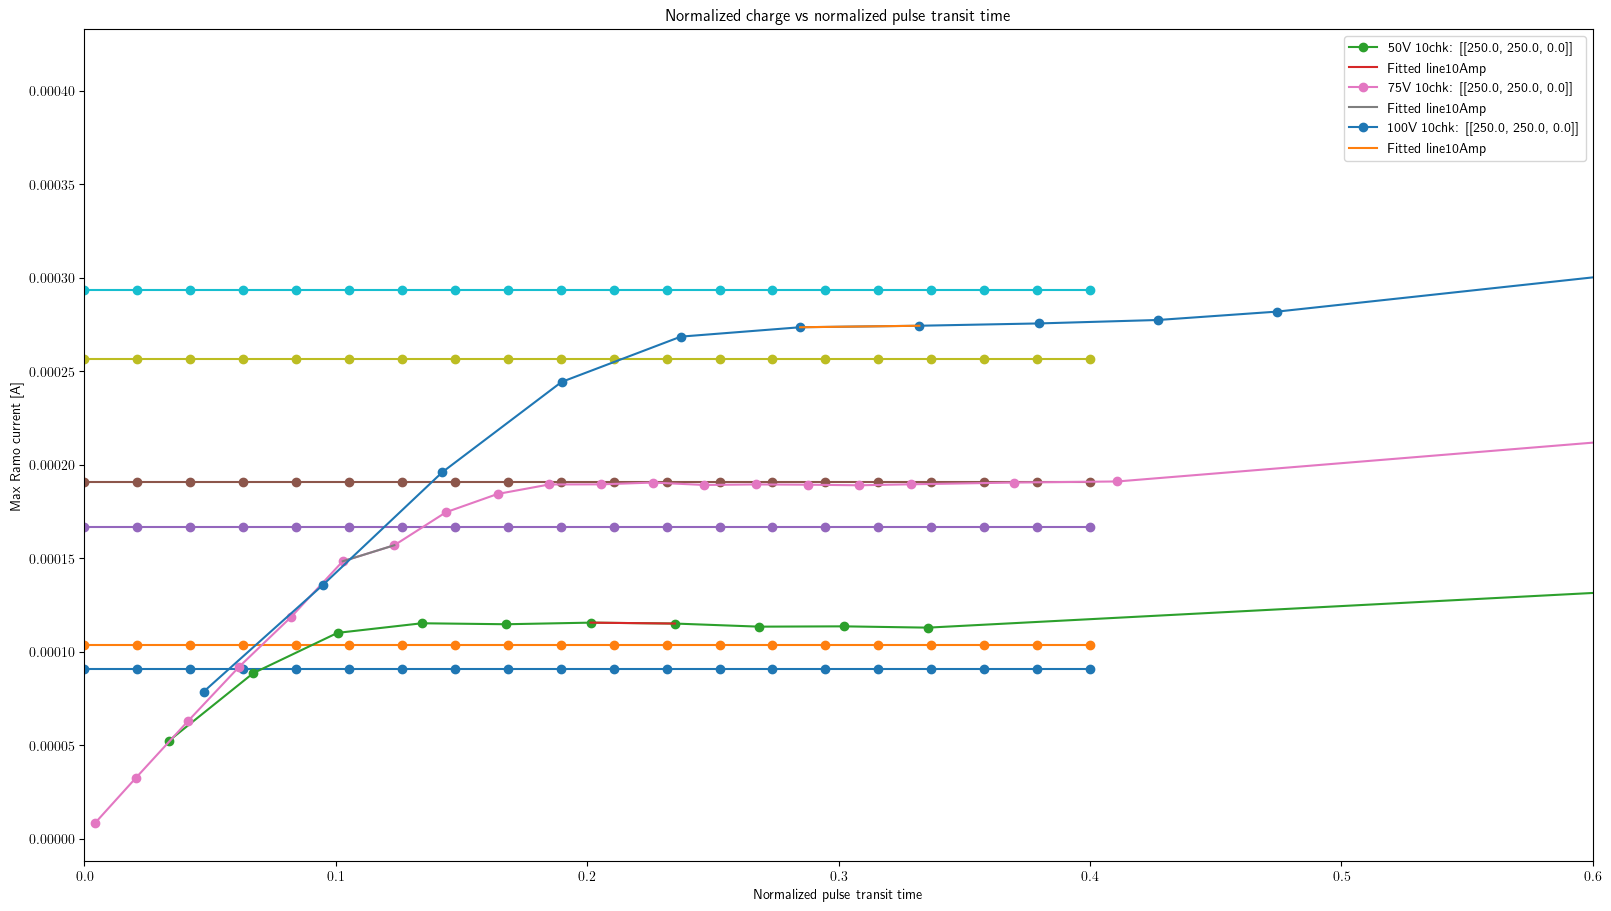

In [23]:
plt.subplots(figsize=(16, 9), constrained_layout=True)
plt.title('Normalized charge vs normalized pulse transit time')

i = 0
#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    plt.plot(np.linspace(0, 0.4, 20), 20*[(pi/9 * epsilon_0 * np.sqrt((2*e)/m_e) * ((x**(3/2)))) * ((4/alpha**2)+(1/alpha))], marker='o', ls='-')
    plt.plot(np.linspace(0, 0.4, 20), 20*[(4/9 * epsilon_0 * np.sqrt((2*e)/m_e) * ((x**(3/2))/(2500.0e-9)**2) * (1+3)) * (pi * (250.0e-9)**2)], marker='o', ls='-')
    #print((pi/9 * epsilon_0 * np.sqrt((2*e)/m_e) * ((x**(3/2)))) * ((4/alpha**2)+(1/alpha)))
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            plt.plot(thisset['norm_tp'], thisset['R_mean'], marker='o', ls='-', label= str(x) + 'V ' + str(y) + 'chk: ' + str(z))#'A E:' + str(z[2:5]))
            
            res = stats.linregress(thisset['norm_tp'][linstart:linend], thisset['R_mean'][linstart:linend])
            plt.plot(thisset['norm_tp'][linstart:linend], res.intercept + res.slope*thisset['norm_tp'][linstart:linend], label='Fitted line' + str(y) + 'Amp')
            print(str(x) + "V "+ f"{y :.1f} Amp " + f"Hallatala: {res.slope}" + f"Skurðpunktur: {res.intercept}")
            #print(f"Max charge {nextset['norm_Q'].max() :.2f}")
            #res2 = stats.linregress(nextset['norm_tp'][7:14], nextset['norm_Q'][7:14])
            #plt.plot(nextset['norm_tp'][7:14], res2.intercept + res2.slope*nextset['norm_tp'][7:14], label='Fitted line flat' + str(y) + 'Amp')
            #plt.plot(nextset['norm_tp'], nextset['norm_I'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            #thisset.to_csv('/home/hakon/Desktop/I_tp_CL_fig'+str(i)+'_long.csv')
            i+=1

plt.xlim([0,0.6])
#plt.ylim([0,0.0002])
plt.xlabel('Normalized pulse transit time')
plt.ylabel('Max Ramo current [A]')
plt.legend()

### Total charge vs pulse transit time

50V 10.0 Amp Hallatala: 0.0004775399478819352Skurðpunktur: 0.09295828830468002
75V 10.0 Amp Hallatala: 0.3290838160885661Skurðpunktur: 0.057582228225959924
100V 10.0 Amp Hallatala: 0.024312364951309885Skurðpunktur: 0.14937092758782006


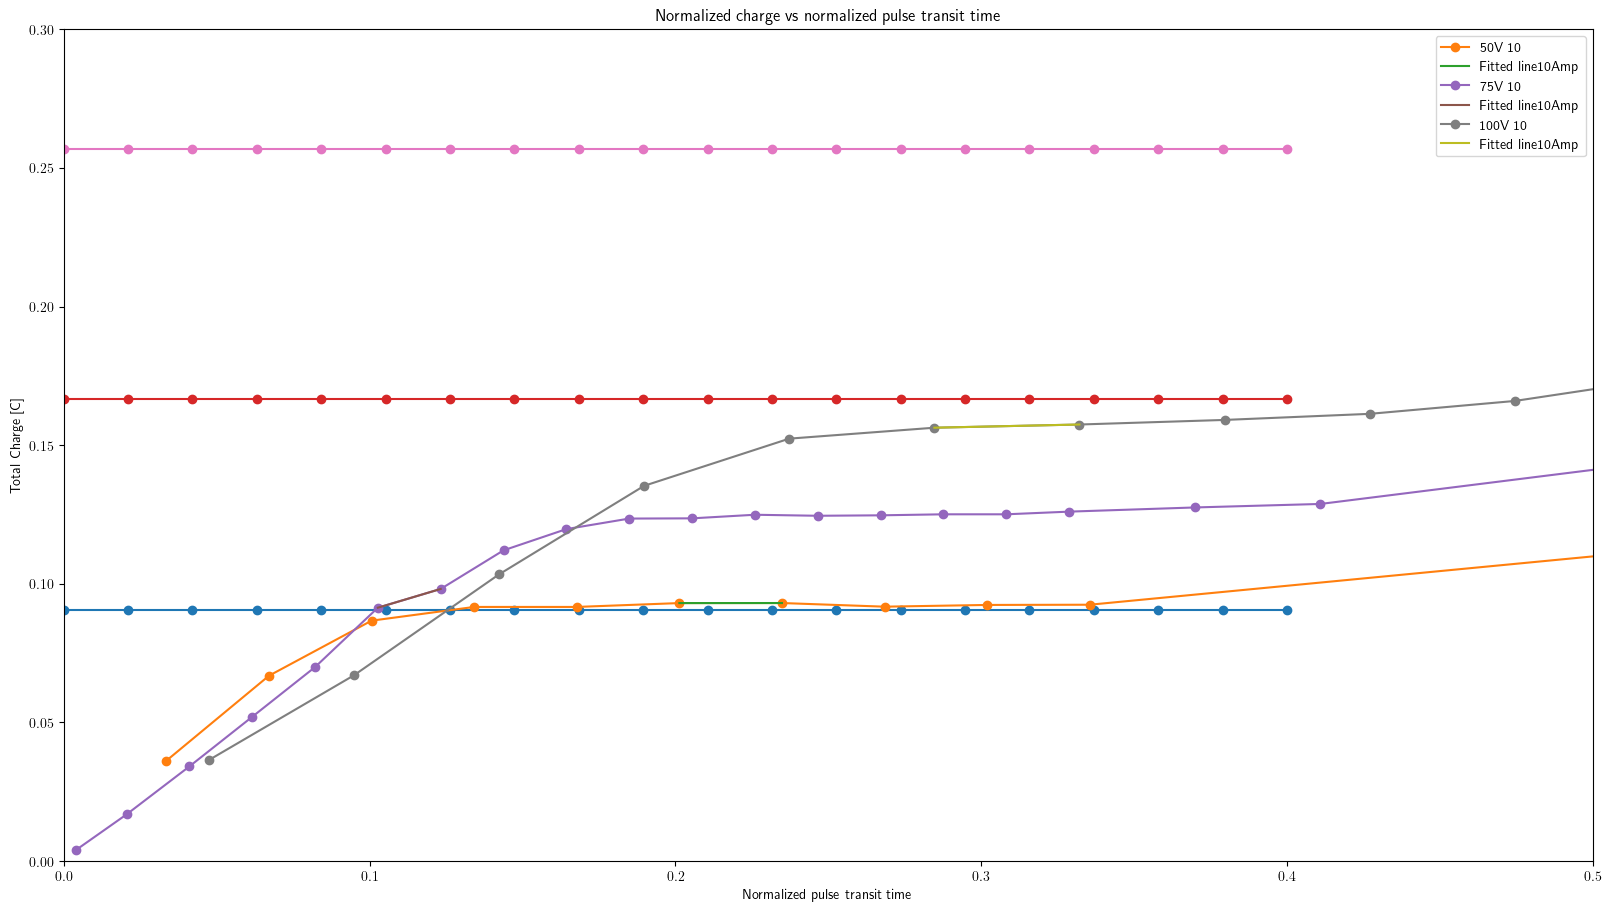

In [24]:
plt.subplots(figsize=(16, 9), constrained_layout=True)
plt.title('Normalized charge vs normalized pulse transit time')
i=0
# Select cases: 
# this_volt_case = [75]#[50, 100]
# this_amp_case  = [1.0, 2.5, 5, 10] #1,2.5,
# this_emitter_size = [str([[250.0, 250.0, 0.0]])] #str([[125.0, 125.0, 0.0]]), str([[250.0, 250.0, 0.0]])

#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    plt.plot(np.linspace(0, 0.4, 20), 20*[(pi/9 * epsilon_0 * np.sqrt((2*e)/m_e) * ((x**(3/2)))) * ((4/alpha**2)+(1/alpha)) * 1e3], marker='o', ls='-')
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            plt.plot(thisset['norm_tp'], thisset['Q_mean']*1e15, marker='o', ls='-', label= str(x) + 'V ' + str(y))# + 'A E:' + str(z[2:5]))
            res = stats.linregress(thisset['norm_tp'][linstart:linend], thisset['Q_mean'][linstart:linend]*1e15)
            plt.plot(thisset['norm_tp'][linstart:linend], res.intercept + res.slope*thisset['norm_tp'][linstart:linend], label='Fitted line' + str(y) + 'Amp')
            print(str(x) + "V "+ f"{y :.1f} Amp " + f"Hallatala: {res.slope}" + f"Skurðpunktur: {res.intercept}")
            #res = stats.linregress(nextset['norm_tp'][0:11], nextset['norm_Q'][0:11])
            #plt.plot(nextset['norm_tp'][0:11], res.intercept + res.slope*nextset['norm_tp'][0:11], label='Fitted line' + str(y) + 'Amp')
            #print(str(x) + "V "+ f"{y :.1f} Amp " + f"Hallatala: {res.slope :.2f}")
            #print(f"Max charge {nextset['norm_Q'].max() :.2f}")
            #res2 = stats.linregress(nextset['norm_tp'][7:14], nextset['norm_Q'][7:14])
            #plt.plot(nextset['norm_tp'][7:14], res2.intercept + res2.slope*nextset['norm_tp'][7:14], label='Fitted line flat' + str(y) + 'Amp')
            #plt.plot(nextset['norm_tp'], nextset['norm_I'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            
plt.xlim([0,0.5])
plt.ylim([0,0.3])

plt.xlabel('Normalized pulse transit time')
plt.ylabel('Total Charge [C]')
plt.legend()

### Total charge vs pulse transit time - Voltage

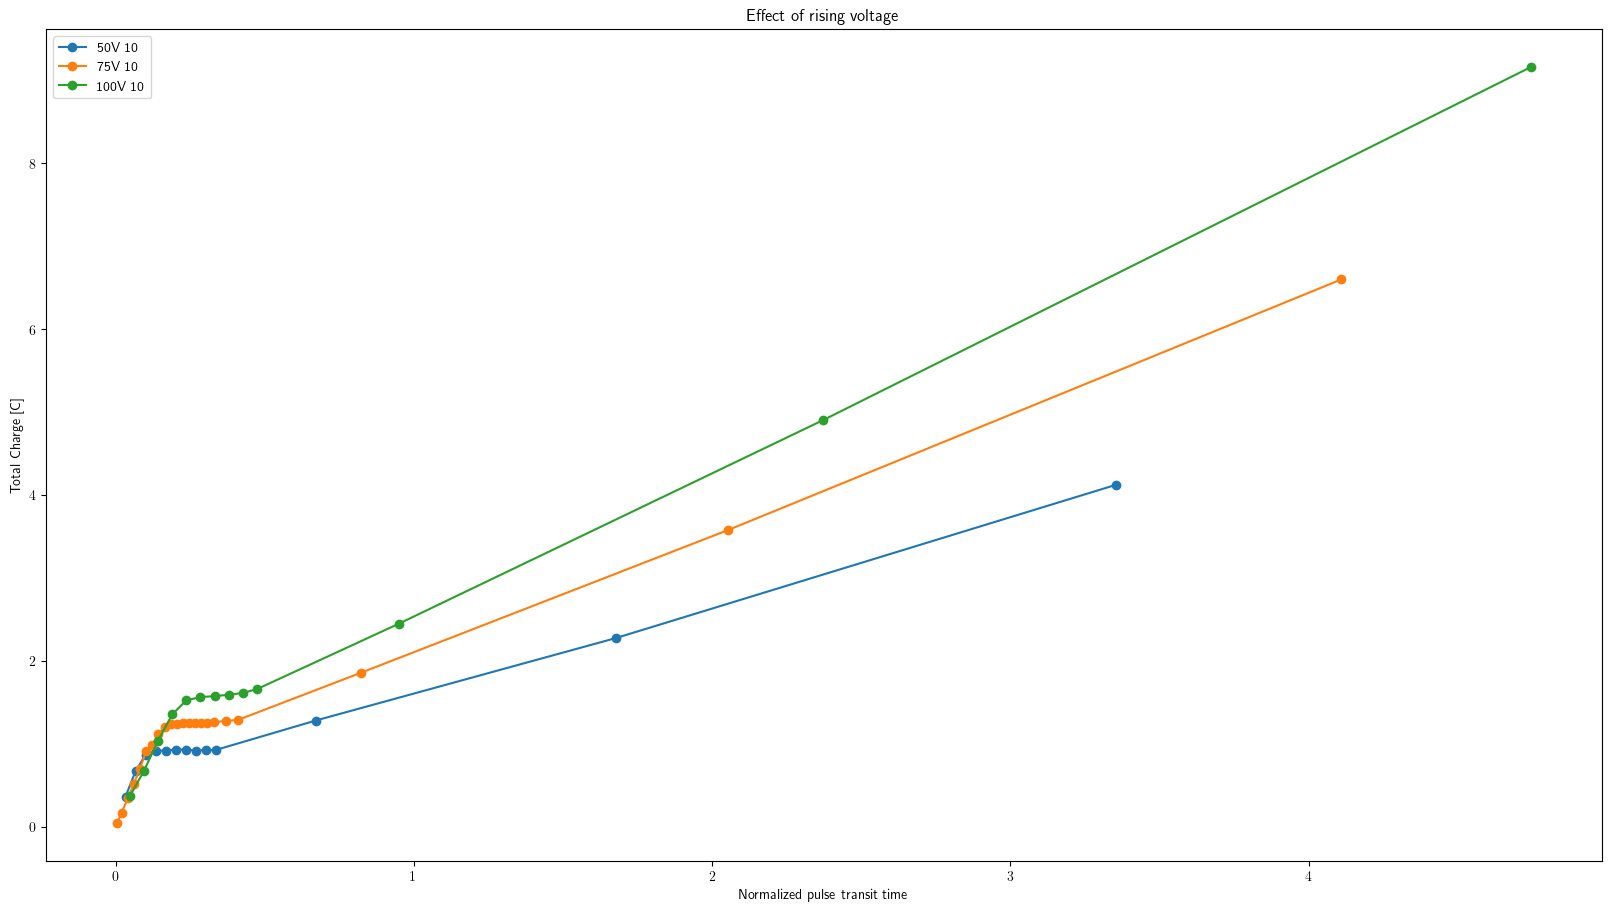

In [25]:
plt.subplots(figsize=(16, 9), constrained_layout=True)
plt.title('Effect of rising voltage')
i=0
# Select cases: 
# this_volt_case = [50, 75, 100]#[50, 100]
# this_amp_case  = [5, 10] #1,2.5,
# this_emitter_size = [str([[250.0, 250.0, 0.0]])] #str([[125.0, 125.0, 0.0]]), str([[250.0, 250.0, 0.0]])
#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            plt.plot(thisset['norm_tp'], thisset['Q_mean']*10e15, marker='o', ls='-', label= str(x) + 'V ' + str(y))# + 'A E:' + str(z[2:5]))
            #res = stats.linregress(nextset['norm_tp'][0:11], nextset['norm_Q'][0:11])
            #plt.plot(nextset['norm_tp'][0:11], res.intercept + res.slope*nextset['norm_tp'][0:11], label='Fitted line' + str(y) + 'Amp')
            #print(str(x) + "V "+ f"{y :.1f} Amp " + f"Hallatala: {res.slope :.2f}")
            #print(f"Max charge {nextset['norm_Q'].max() :.2f}")
            #res2 = stats.linregress(nextset['norm_tp'][7:14], nextset['norm_Q'][7:14])
            #plt.plot(nextset['norm_tp'][7:14], res2.intercept + res2.slope*nextset['norm_tp'][7:14], label='Fitted line flat' + str(y) + 'Amp')
            #plt.plot(nextset['norm_tp'], nextset['norm_I'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            #thisset.to_csv('/home/hakon/Desktop/Q_tp_Volt_fig'+str(i)+'.csv')
            #i+=1
#plt.xlim([0,1])
#plt.ylim([0,4])
plt.xlabel('Normalized pulse transit time')
plt.ylabel('Total Charge [C]')
plt.legend()

### Total charge vs norm tp - emitter size

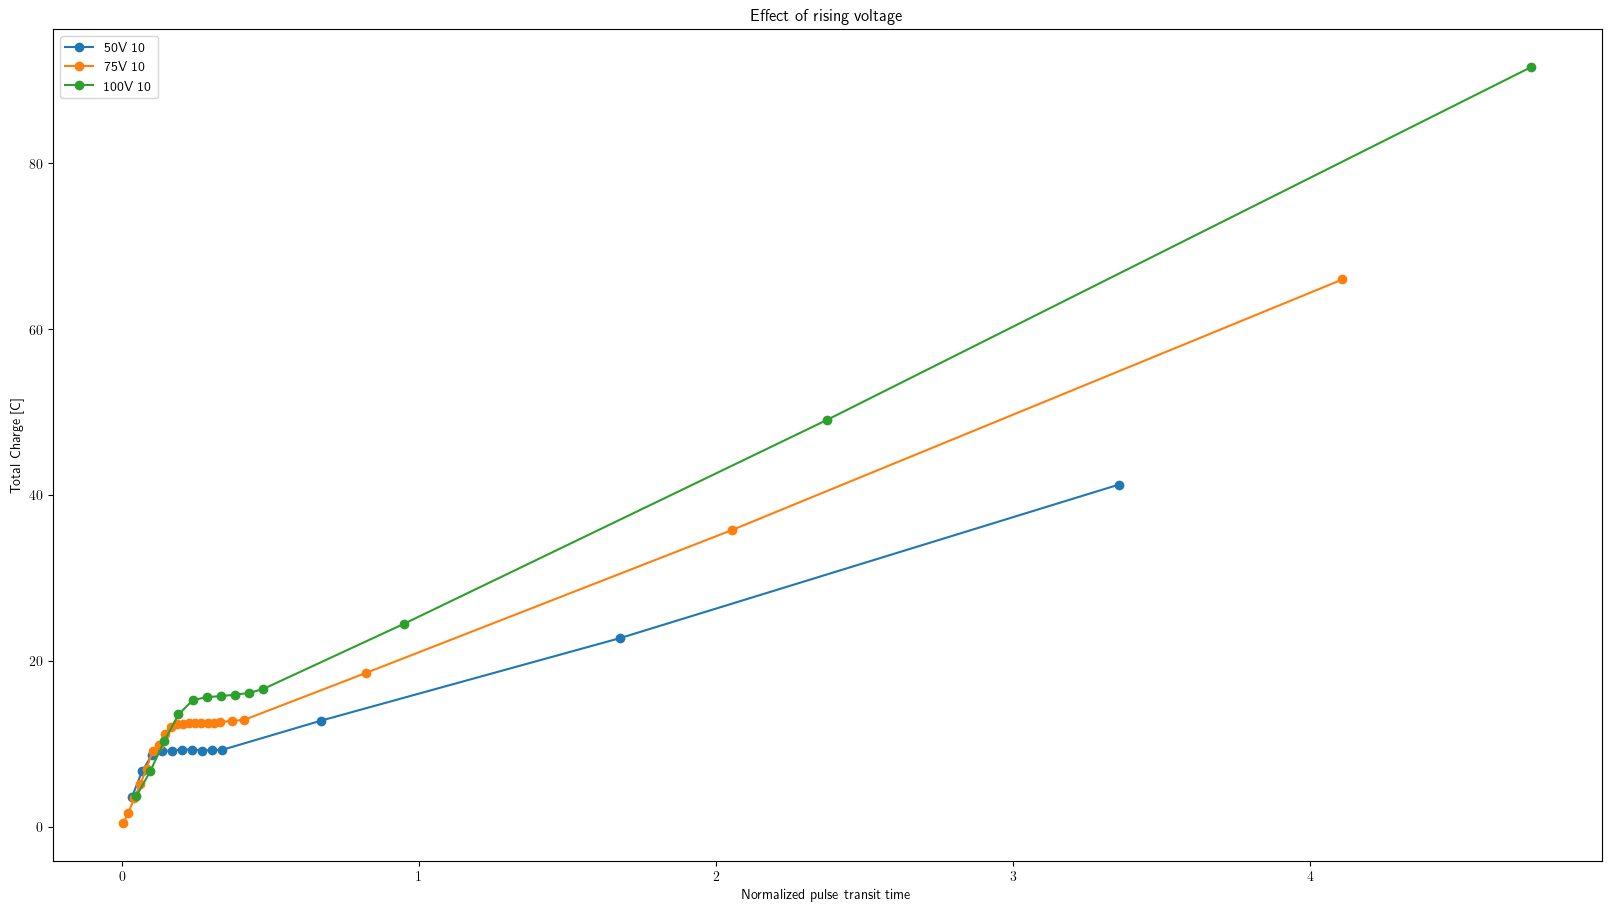

In [26]:
plt.subplots(figsize=(16, 9), constrained_layout=True)
plt.title('Effect of rising voltage')
i=0
# Select cases: 
# this_volt_case = [75]#[50, 100]
# this_amp_case  = [5, 10] #1,2.5,
# this_emitter_size = [str([[125.0, 125.0, 0.0]]), str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])]
#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            plt.plot(thisset['norm_tp'], thisset['Q_mean']/10e-18, marker='o', ls='-', label= str(x) + 'V ' + str(y))# + 'A E:' + str(z[2:5]))
            #res = stats.linregress(nextset['norm_tp'][0:11], nextset['norm_Q'][0:11])
            #plt.plot(nextset['norm_tp'][0:11], res.intercept + res.slope*nextset['norm_tp'][0:11], label='Fitted line' + str(y) + 'Amp')
            #print(str(x) + "V "+ f"{y :.1f} Amp " + f"Hallatala: {res.slope :.2f}")
            #print(f"Max charge {nextset['norm_Q'].max() :.2f}")
            #res2 = stats.linregress(nextset['norm_tp'][7:14], nextset['norm_Q'][7:14])
            #plt.plot(nextset['norm_tp'][7:14], res2.intercept + res2.slope*nextset['norm_tp'][7:14], label='Fitted line flat' + str(y) + 'Amp')
            #plt.plot(nextset['norm_tp'], nextset['norm_I'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            #thisset.to_csv('/home/hakon/Desktop/Q_tp_emitter_size_fig'+str(i)+'.csv')
            #i+=1
#plt.xlim([0,1])
#plt.ylim([0,4])
plt.xlabel('Normalized pulse transit time')
plt.ylabel('Total Charge [C]')
plt.legend()

### Brightness vs normalized pulse transit time

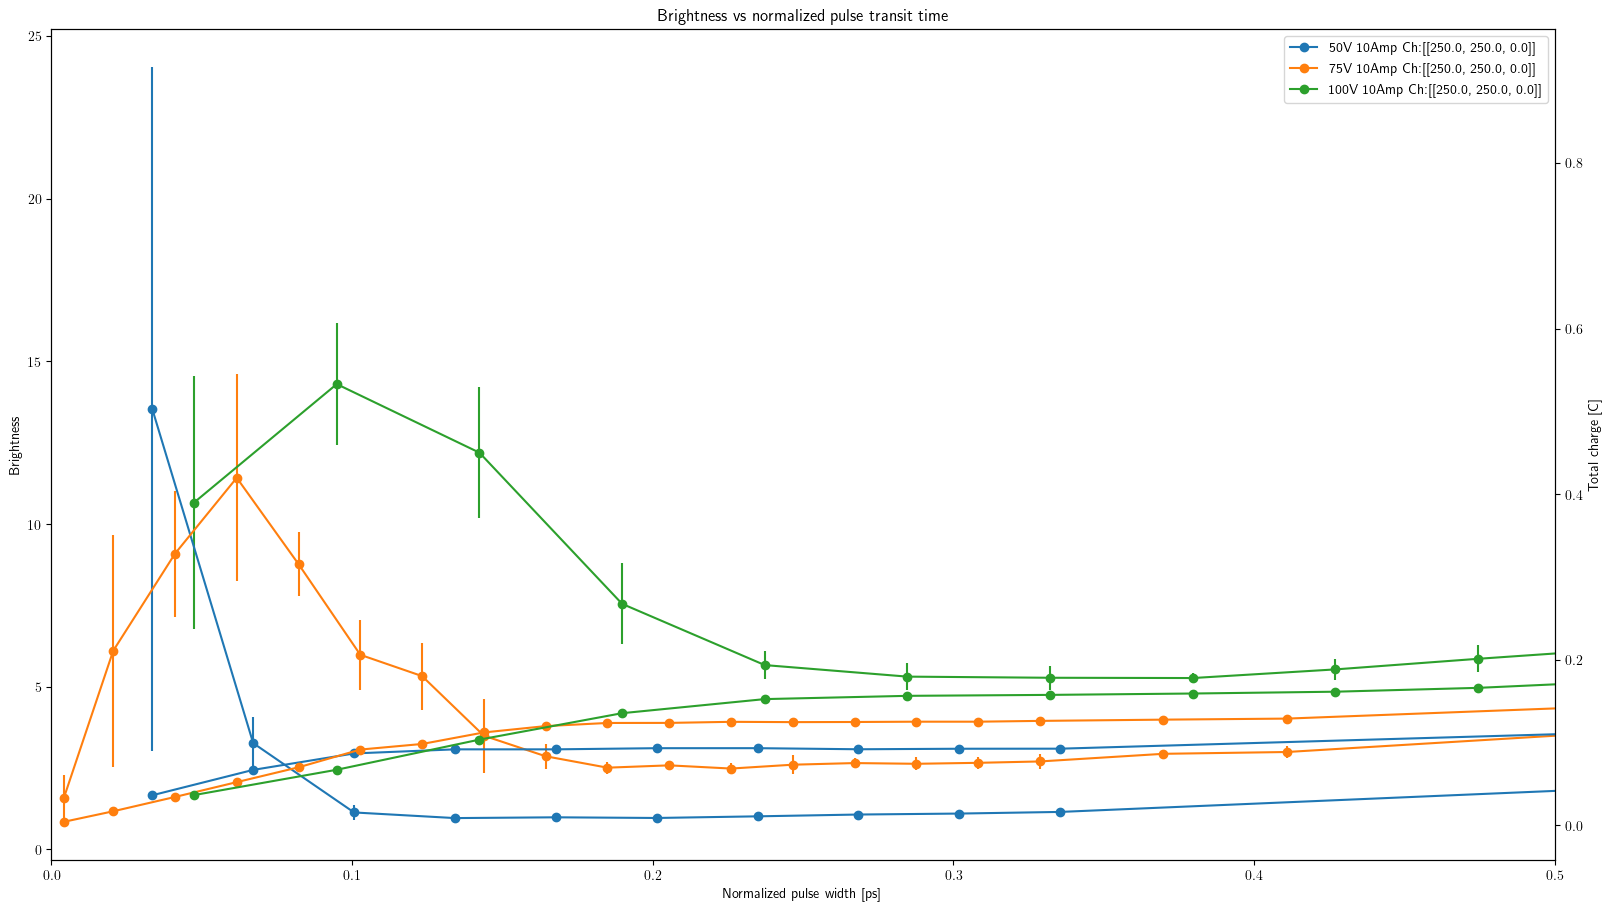

In [27]:
bfig, bax = plt.subplots(figsize=(16, 9), constrained_layout=True)
plt.title('Brightness vs normalized pulse transit time')
bax1 = bax.twinx()
i=0
# Select cases: 
#this_volt_case = [50, 75, 100]#[50, 100]
#this_amp_case  = [5]
#this_emitter_size = [str([[250.0, 250.0, 0.0]])]#[str([[125.0, 125.0, 0.0]]), str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])]#, str([[250.0, 250.0, 0.0]])] #[8, 10]
#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            bax.errorbar(thisset['norm_tp'], thisset['B_mean'],  thisset['B_std'], marker='o', ls='-', label=str(x)+'V '+ str(y) + 'Ch:'+ str(z))#+'A E:'+ z[2:5])
            bax1.plot(thisset['norm_tp'], thisset['Q_mean']*1e15, marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp '+ 'Ch:'+ str(z))
            #plt.plot(thisset['norm_tp'], thisset['P_start'], marker='o')
            
            #print(thisset['B_mean'][0:15].max())50
            # z = np.polyfit(nextset['norm_tp'], nextset['B_mean'], 4)
            # c = np.poly1d(z)
            # plt.plot(nextset['norm_tp'], c(nextset['norm_tp']),"r--")
            #plt.plot(nextset['norm_tp'], nextset['norm_Q'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            #res = stats.linregress(nextset['norm_tp'][0:6], nextset['norm_Q'][0:6])
            #plt.plot(nextset['norm_tp'][0:6], res.intercept + res.slope*nextset['norm_tp'][0:6], label='Fitted line' + str(y) + 'Amp')
            #print(str(x) + "V "+ f"{y :.1f} Amp " + f"Hallatala: {res.slope :.2f}")
            #res2 = stats.linregress(nextset['norm_tp'][7:14], nextset['norm_Q'][7:14])
            #plt.plot(nextset['norm_tp'][7:14], res2.intercept + res2.slope*nextset['norm_tp'][7:14], label='Fitted line flat' + str(y) + 'Amp')
            #plt.plot(nextset['norm_tp'], nextset['norm_I'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            #thisset.to_csv('/home/hakon/Desktop/B_tp_V_fig'+str(i)+'.csv')
            #i+=1
            
plt.xlim([0,0.5])
#plt.ylim([0,20])
bax.set_ylabel('Brightness')
bax.set_xlabel('Normalized pulse width [ps]')
bax1.set_ylabel('Total charge [C]')
plt.legend() # The Brightness max is around 40% (~33-43%) of total charge

## Brightness std vs average Brightness

Text(0.5, 0, 'Brightness')

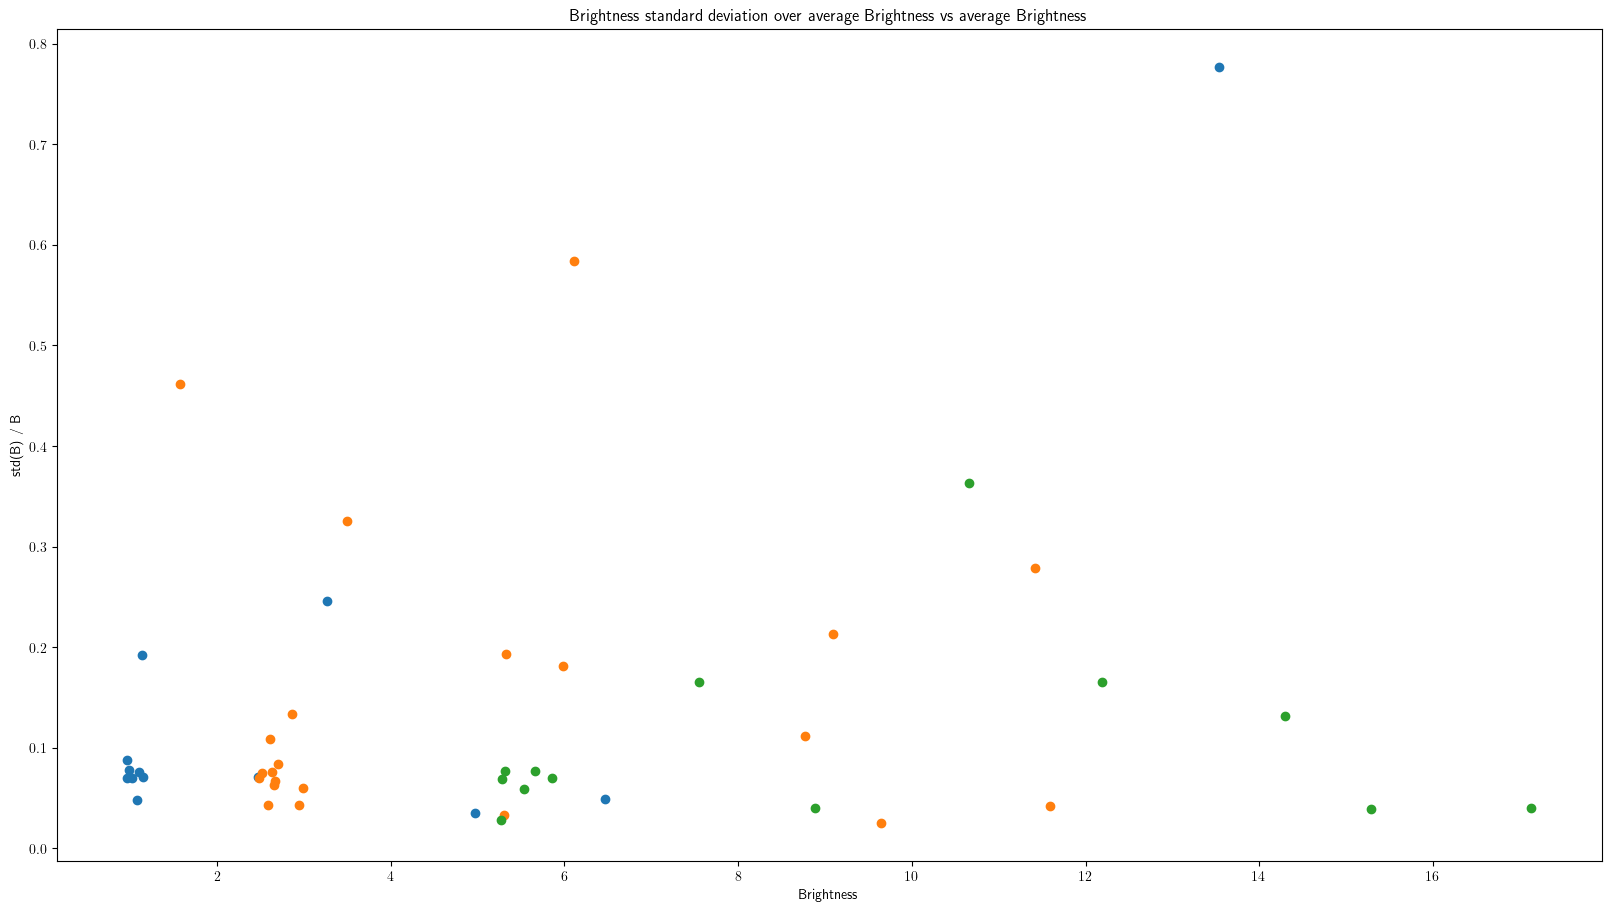

In [28]:
plt.subplots(figsize=(16, 9), constrained_layout=True)
plt.title('Brightness standard deviation over average Brightness vs average Brightness')
# Select cases: 
# this_volt_case =  [50, 75, 100]#[50, 100]
# this_amp_case  = [2.5, 5, 10]
# this_emitter_size = [str([[125.0, 125.0, 0.0]]), str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])]
#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            plt.scatter(thisset['B_mean'], (thisset['B_std']/thisset['B_mean']), marker='o')

#plt.xlim([0,1000])
#plt.ylim([0,1])
plt.ylabel('std(B) / B')
plt.xlabel('Brightness')
#plt.legend()

## 3x3 Brightness / Charge graph

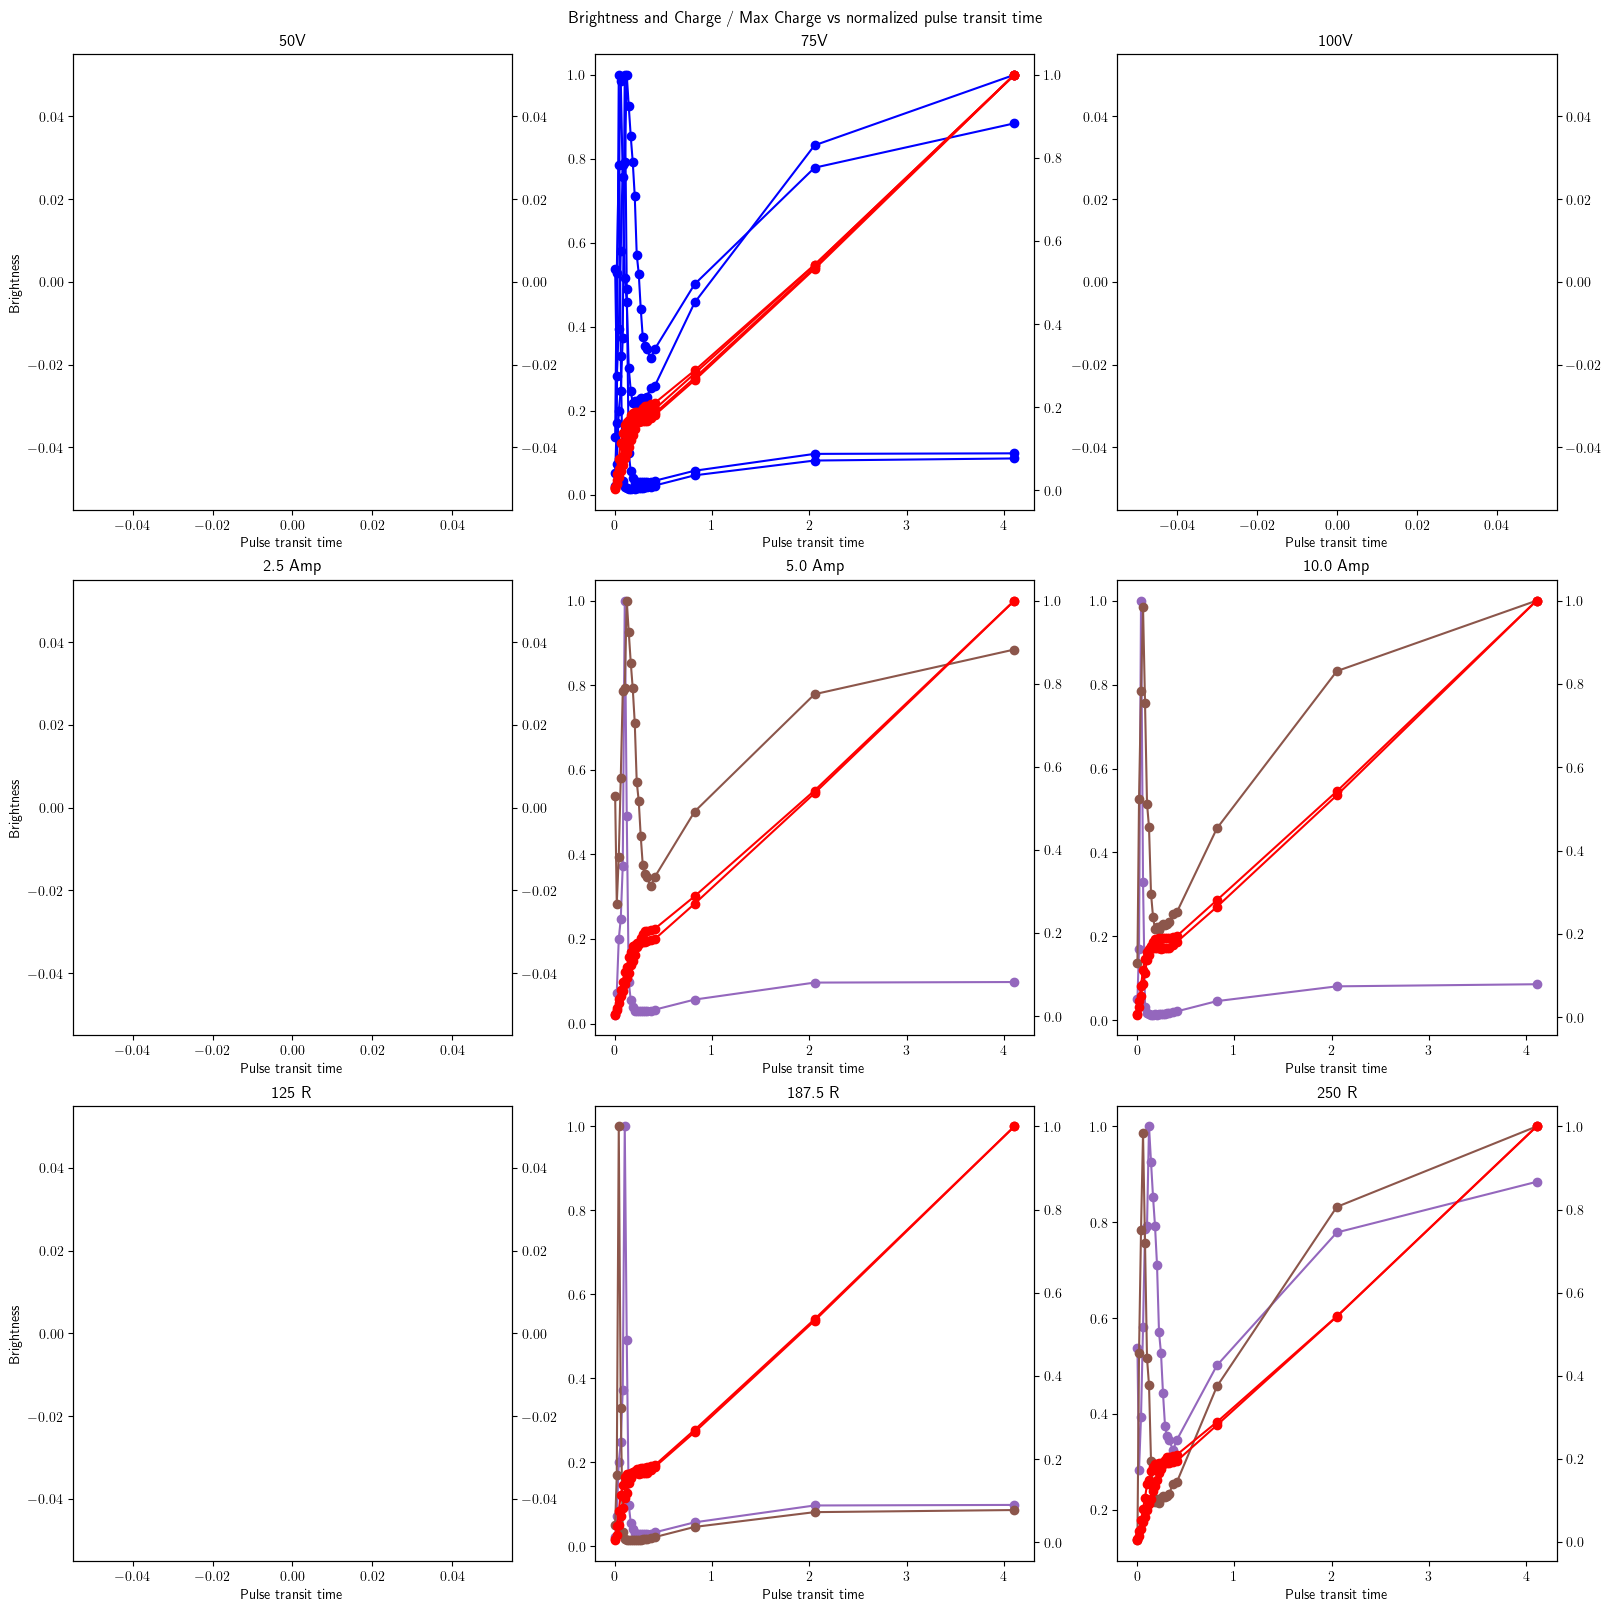

In [29]:
# Select cases: 
this_volt_case = [0, 75, 0]#[50, 75, 100]
this_amp_case  = [0, 5, 10] #[2.5, 5, 10]
this_emitter_size = [0, str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])]# str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])] #[str([[125.0, 125.0, 0.0]]),
this_pw_case = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100, 200, 500, 1000]
#------------------------------------------------------------------------------------------#
# Create figure
fig_dim = 3
fig, axs = plt.subplots(fig_dim,fig_dim,figsize=(16, 16), constrained_layout=True)
ax1 = axs[0, 0].twinx()
ax2 = axs[0, 1].twinx()
ax3 = axs[0, 2].twinx()
ax4 = axs[1, 0].twinx()
ax5 = axs[1, 1].twinx()
ax6 = axs[1, 2].twinx()
ax7 = axs[2, 0].twinx()
ax8 = axs[2, 1].twinx()
ax9 = axs[2, 2].twinx()

# Plot error bar graph from statistical set
for x in this_volt_case[0:1]:    
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            axs[0,0].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', color='blue', label=str(this_volt_case[0:1])[1:3]+'V')
            ax1.plot(thisset['norm_tp'], (thisset['Q_mean']/(thisset['Q_mean'].max())),  marker='o', color='red')
for x in this_volt_case[1:2]:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            axs[0,1].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', color='blue',label=str(this_volt_case[1:2])[1:3]+'V')
            ax2.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
for x in this_volt_case[2:3]:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            axs[0,2].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', label=str(this_volt_case[2:3])[1:4]+'V')
            ax3.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
for x in this_amp_case[0:1]:
    errorset        = statistical_set[statistical_set['Amplitude'] == x ]
    for y in this_volt_case:
        nextset        = errorset[errorset['Voltage'] == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            axs[1,0].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', label=str(this_amp_case[0:1])+'Amp')
            ax4.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
for x in this_amp_case[1:2]:
    errorset        = statistical_set[statistical_set['Amplitude'] == x ]
    for y in this_volt_case:
        nextset        = errorset[errorset['Voltage'] == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            axs[1,1].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', label=str(this_amp_case[1:2])+'Amp')
            ax5.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
for x in this_amp_case[2:3]:
    errorset        = statistical_set[statistical_set['Amplitude'] == x ]
    for y in this_volt_case:
        nextset        = errorset[errorset['Voltage']               == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            axs[1,2].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', label=str(this_amp_case[2:3])+'Amp')
            ax6.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
for x in this_emitter_size[0:1]:
    errorset        = statistical_set[statistical_set['Emitter'] == x ]
    for y in this_volt_case:
        nextset        = errorset[errorset['Voltage']            == y ]
        for z in this_amp_case:
            thisset = nextset[ nextset['Amplitude']              == z ]
            axs[2,0].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', label=str(this_emitter_size[0:1])[4:9]+'nm radius')
            ax7.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
for x in this_emitter_size[1:2]:
    errorset        = statistical_set[statistical_set['Emitter'] == x ]
    for y in this_volt_case:
        nextset        = errorset[errorset['Voltage']            == y ]
        for z in this_amp_case:
            thisset = nextset[ nextset['Amplitude']              == z ]
            axs[2,1].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', label=str(this_emitter_size[1:2])[4:9]+'nm radius')
            ax8.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
for x in this_emitter_size[2:3]:
    errorset        = statistical_set[statistical_set['Emitter'] == x ]
    for y in this_volt_case:
        nextset        = errorset[errorset['Voltage']            == y ]
        for z in this_amp_case:
            thisset = nextset[ nextset['Amplitude']              == z ]
            axs[2,2].plot(thisset['norm_tp'], thisset['B_mean']/thisset['B_mean'].max(),  marker='o', label=str(this_emitter_size[2:3])[4:9]+'nm radius')
            ax9.plot(thisset['norm_tp'], thisset['Q_mean']/(thisset['Q_mean'].max()),  marker='o', color='red')
# Set axis limitations
#axs[0].set_ylim((0, 2E-16))
# Set title
fig.suptitle('Brightness and Charge / Max Charge vs normalized pulse transit time')
axs[0,0].set_title('50V')
axs[0,1].set_title('75V')
axs[0,2].set_title('100V')
axs[1,0].set_title('2.5 Amp')
axs[1,1].set_title('5.0 Amp')
axs[1,2].set_title('10.0 Amp')
axs[2,0].set_title('125 R')
axs[2,1].set_title('187.5 R')
axs[2,2].set_title('250 R')
# Label axii
for x in range(0, fig_dim):
    axs[x, 0].set_ylabel('Brightness')
    
    for y in range(0, fig_dim):
        axs[x, y].set_xlabel('Pulse transit time')
        #axs[x, y].set_xlim((0,0.5))
        #axs[x, y].set_ylim((0,800))
        #axs[x,y].legend()



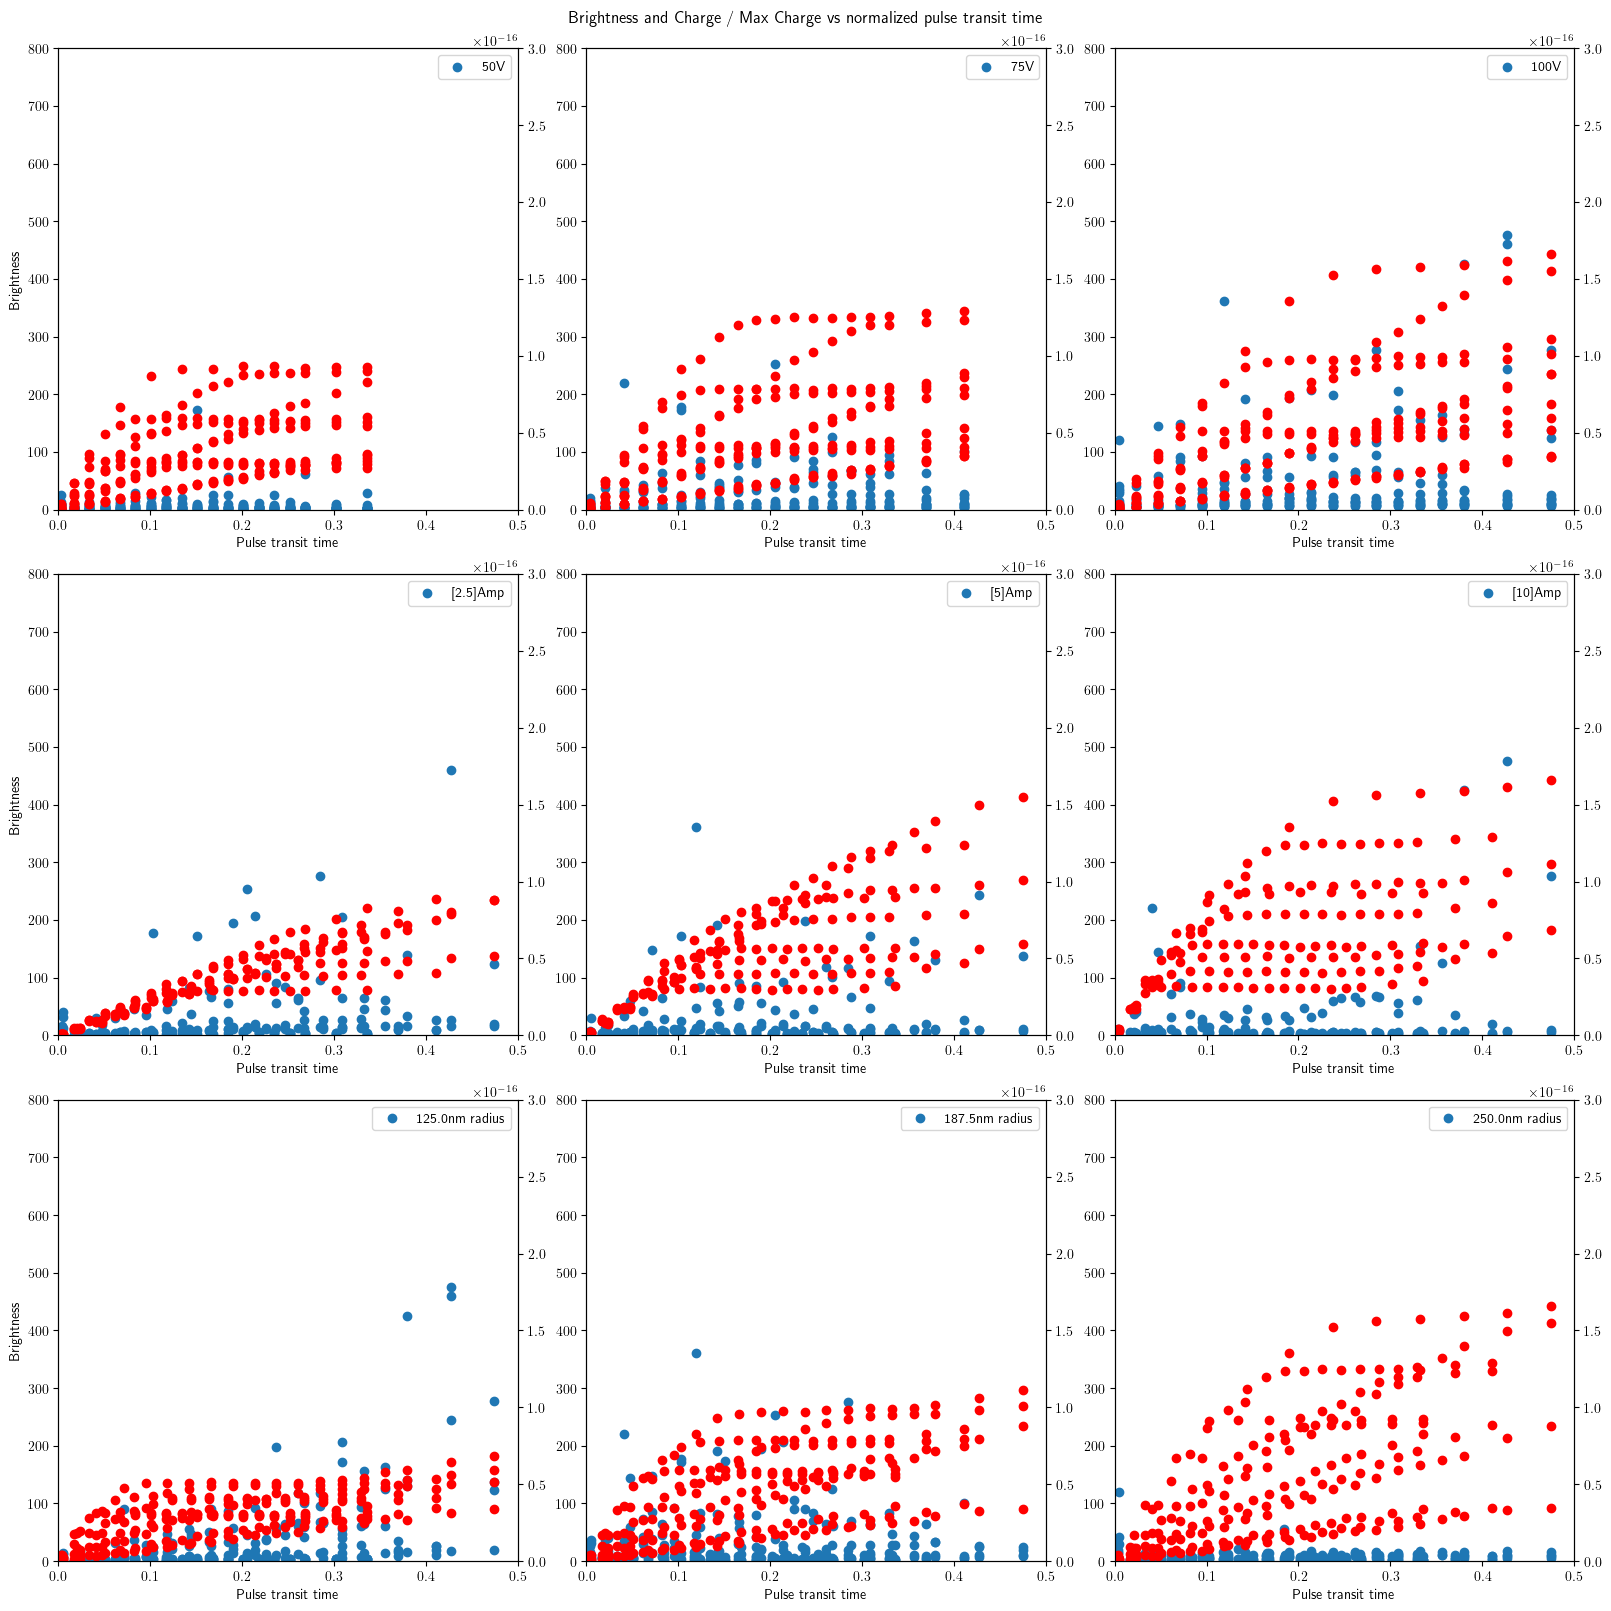

In [30]:
# Select cases: 
this_volt_case = [50, 75, 100]#[50, 100]
this_amp_case  = [2.5, 5, 10]
this_emitter_size = [str([[125.0, 125.0, 0.0]]), str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])]
this_pw_case = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90, 100, 200, 500, 1000]
#aa = statistical_set.drop(statistical_set[statistical_set['Pulse_width'] > 100]dex > 100)
#------------------------------------------------------------------------------------------#
# Create figure
fig_dim = 3
fig, axs = plt.subplots(fig_dim,fig_dim,figsize=(16, 16), constrained_layout=True)
ax1 = axs[0, 0].twinx()
ax2 = axs[0, 1].twinx()
ax3 = axs[0, 2].twinx()
ax4 = axs[1, 0].twinx()
ax5 = axs[1, 1].twinx()
ax6 = axs[1, 2].twinx()
ax7 = axs[2, 0].twinx()
ax8 = axs[2, 1].twinx()
ax9 = axs[2, 2].twinx()

# Plot error bar graph from statistical set
for x in this_volt_case[0:1]:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    axs[0,0].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_volt_case[0:1])[1:3]+'V')
    ax1.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_volt_case[1:2]:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    axs[0,1].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_volt_case[1:2])[1:3]+'V')
    ax2.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_volt_case[2:3]:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    axs[0,2].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_volt_case[2:3])[1:4]+'V')
    ax3.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_amp_case[0:1]:
    errorset        = statistical_set[statistical_set['Amplitude'] == x ]
    axs[1,0].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_amp_case[0:1])+'Amp')
    ax4.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_amp_case[1:2]:
    errorset        = statistical_set[statistical_set['Amplitude'] == x ]
    axs[1,1].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_amp_case[1:2])+'Amp')
    ax5.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_amp_case[2:3]:
    errorset        = statistical_set[statistical_set['Amplitude'] == x ]
    axs[1,2].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_amp_case[2:3])+'Amp')    
    ax6.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_emitter_size[0:1]:
    errorset        = statistical_set[statistical_set['Emitter'] == x ]
    axs[2,0].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_emitter_size[0:1])[4:9]+'nm radius')
    ax7.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_emitter_size[1:2]:
    errorset        = statistical_set[statistical_set['Emitter'] == x ]
    axs[2,1].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_emitter_size[1:2])[4:9]+'nm radius')
    ax8.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
for x in this_emitter_size[2:3]:
    errorset        = statistical_set[statistical_set['Emitter'] == x ]
    axs[2,2].scatter(errorset['norm_tp'], errorset['B_mean'],  marker='o', label=str(this_emitter_size[2:3])[4:9]+'nm radius') 
    ax9.scatter(errorset['norm_tp'], errorset['Q_mean'],  marker='o', color='red')
# Set axis limitations
#axs[0].set_ylim((0, 2E-16))
# Set title
fig.suptitle('Brightness and Charge / Max Charge vs normalized pulse transit time')
# Label axii
ax1.set_ylim((0,3e-16))
ax2.set_ylim((0,3e-16))
ax3.set_ylim((0,3e-16))
ax4.set_ylim((0,3e-16))
ax5.set_ylim((0,3e-16))
ax6.set_ylim((0,3e-16))
ax7.set_ylim((0,3e-16))
ax8.set_ylim((0,3e-16))
ax9.set_ylim((0,3e-16))
for x in range(0, fig_dim):
    axs[x, 0].set_ylabel('Brightness')
    
    for y in range(0, fig_dim):
        axs[x, y].set_xlabel('Pulse transit time')
        axs[x, y].set_xlim((0,0.5))
        axs[x, y].set_ylim((0,800))
        axs[x,y].legend()



## Normalized current vs normalized pulse transit time

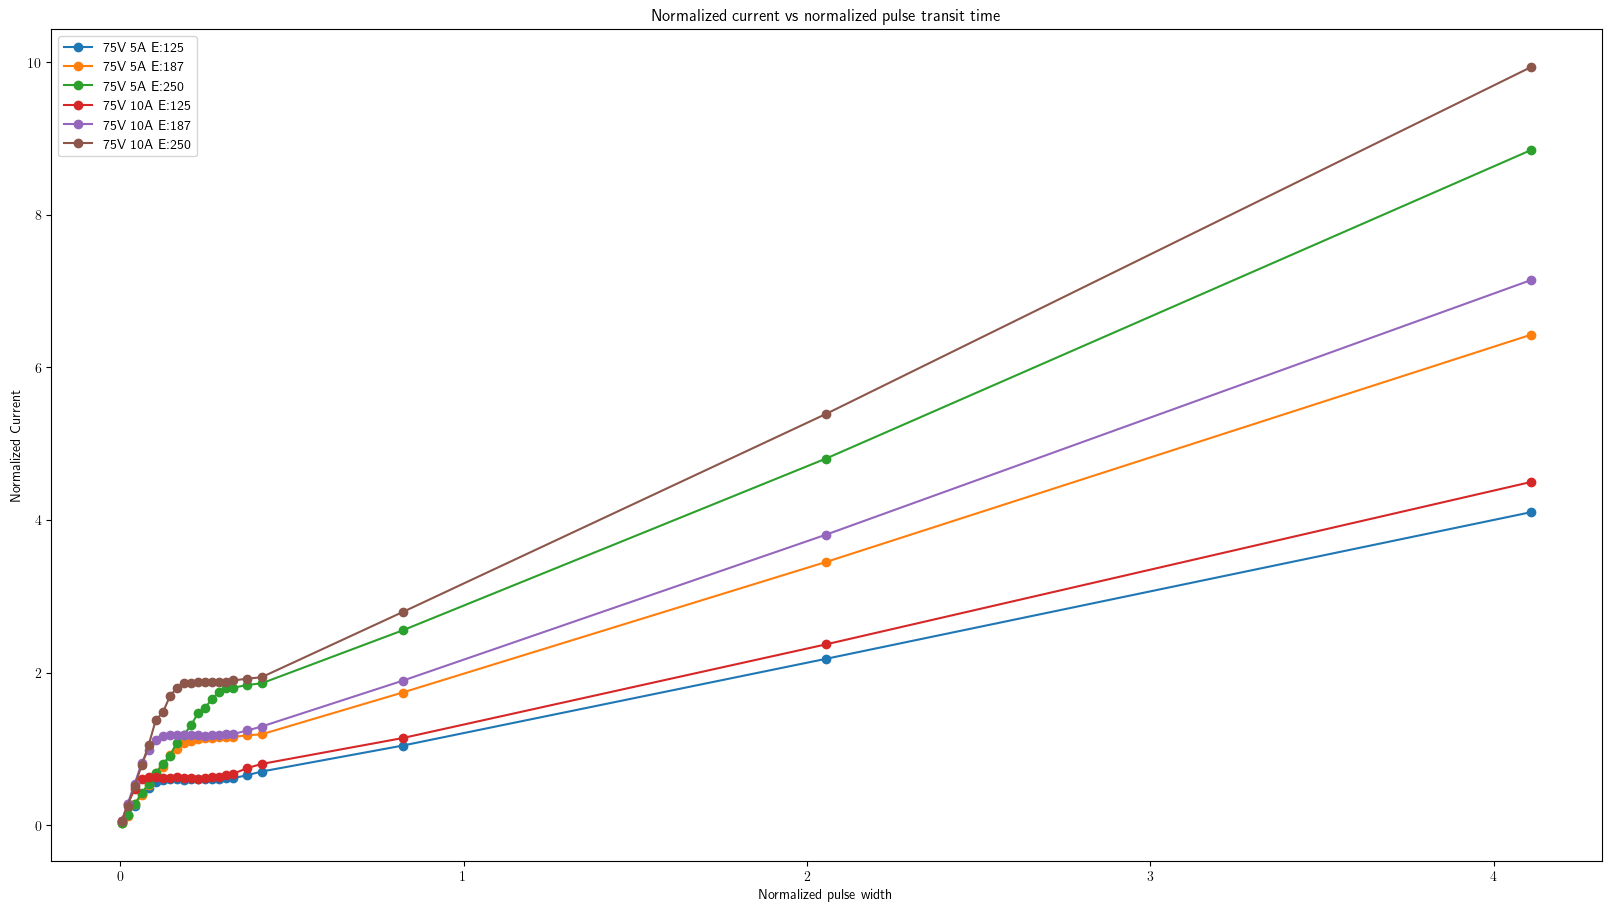

In [31]:
plt.subplots(figsize=(16, 9), constrained_layout=True)
plt.title('Normalized current vs normalized pulse transit time')
# Select cases: 
this_volt_case = [75] #[50, 100]
this_amp_case  = [5, 10]
this_emitter_size = [str([[125.0, 125.0, 0.0]]), str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])]
#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            plt.plot(thisset['norm_tp'], thisset['norm_Q'], marker='o', ls='-', label=str(x)+'V '+str(y)+'A E:' + str(z[2:5]))
            #print(nextset['norm_I'][0:10].max())
            #print(str(x) + 'V' + str(y) + ' Amp')
            #res = stats.linregress(nextset['norm_tp'][0:11], nextset['norm_I'][0:11])
            #plt.plot(nextset['norm_tp'][0:11], res.intercept + res.slope*nextset['norm_tp'][0:11], label='Fitted line' + str(y) + 'Amp')
            #print(str(x) + "V "+ f"{y :.1f} Amp " + f"Hallatala: {res.slope :.2f}")
            #plt.plot(nextset['norm_tp'], nextset['norm_I'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
#plt.xlim([0,1])
#plt.ylim([0,2])
plt.xlabel('Normalized pulse width')
plt.ylabel('Normalized Current')
plt.legend()

## Emittance vs normalized pulse transit time

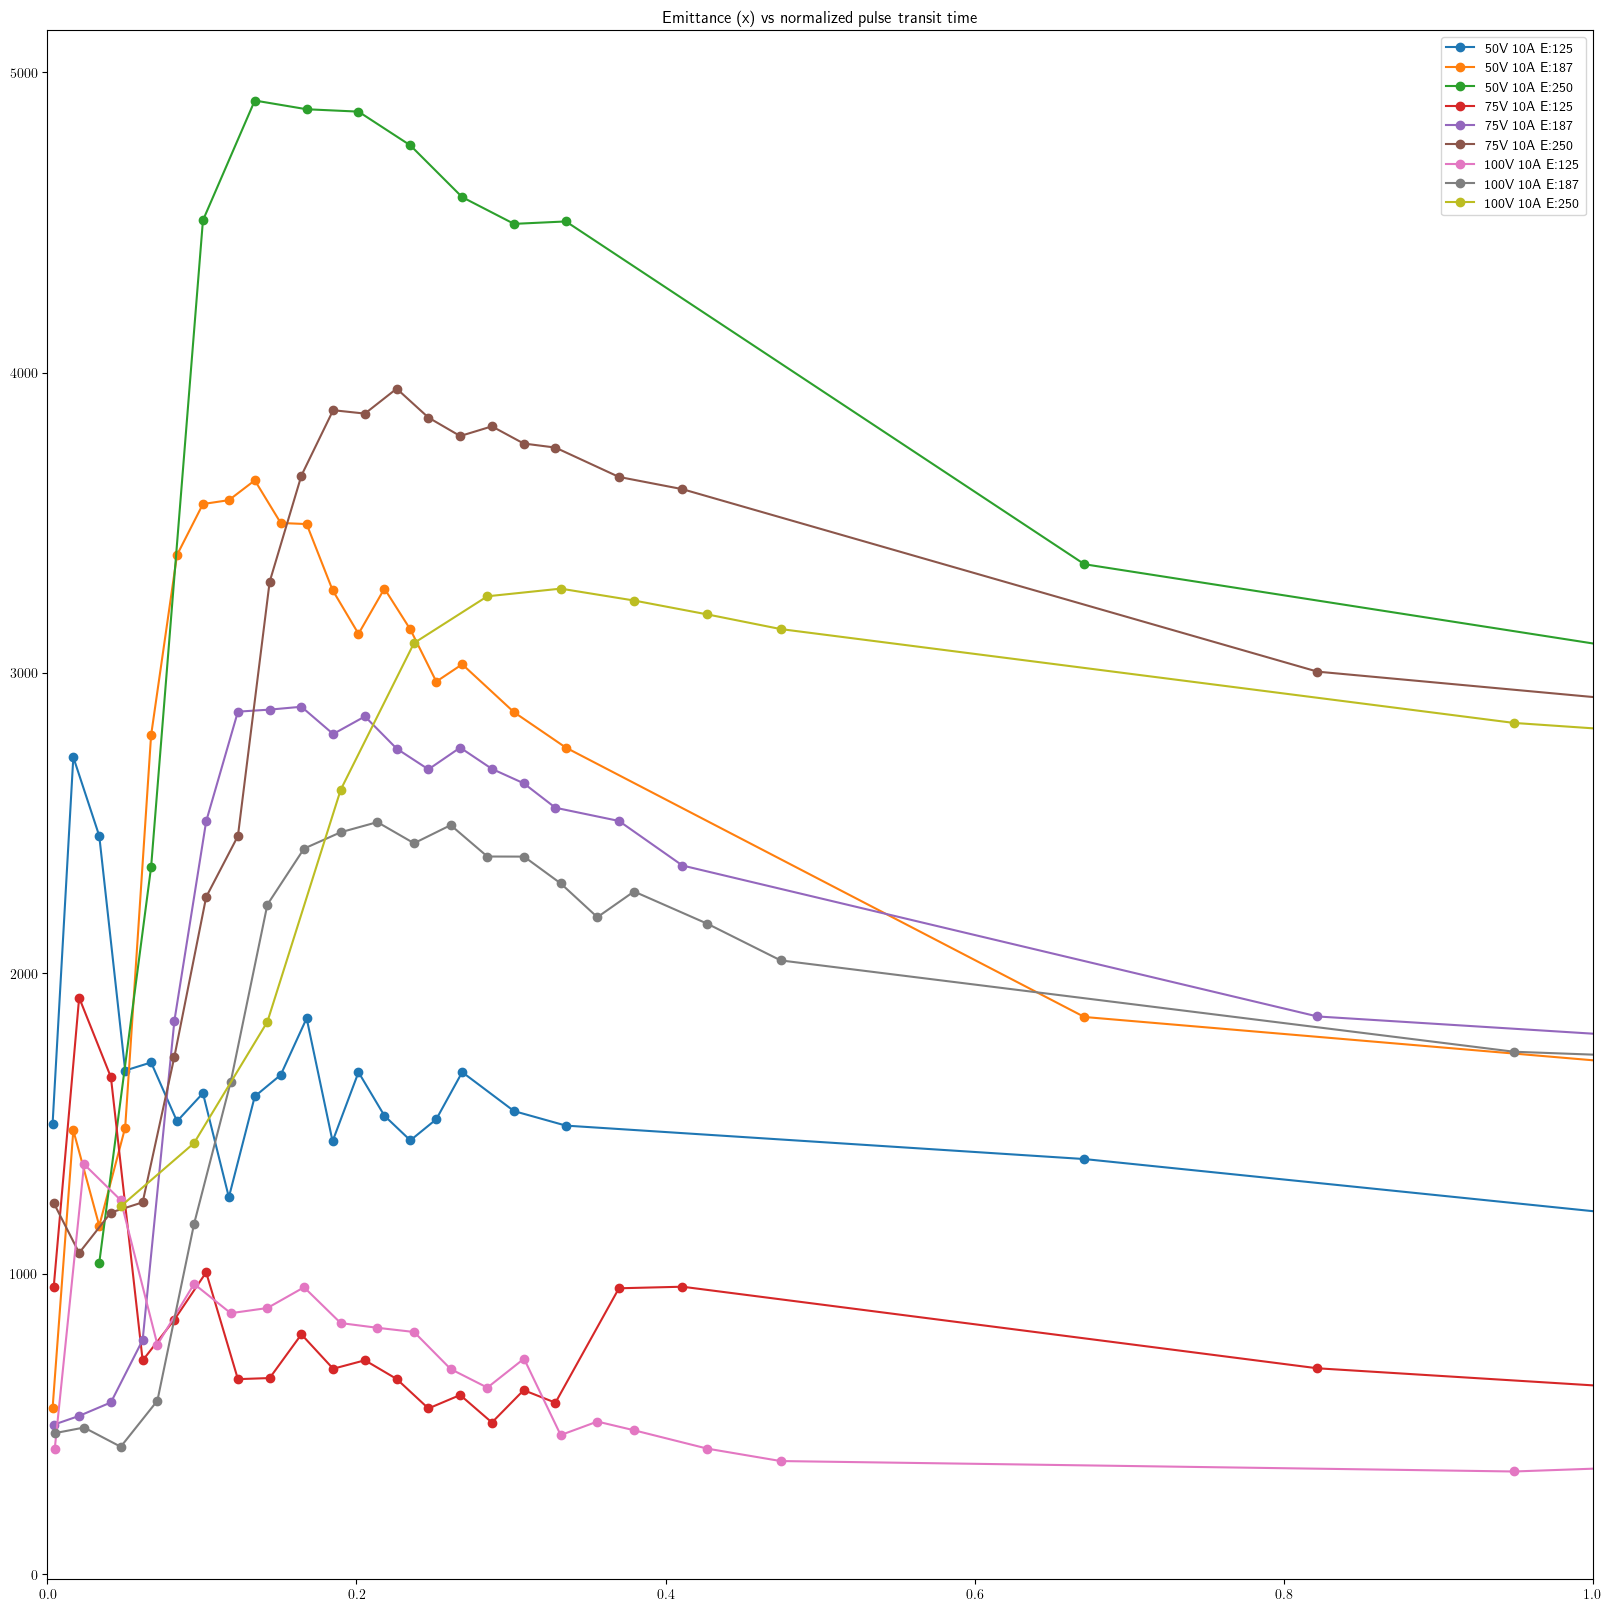

In [32]:
plt.subplots(figsize=(16, 16), constrained_layout=True)
plt.title('Emittance (x) vs normalized pulse transit time')
# Select cases: 
this_volt_case = [50, 75, 100]
this_amp_case  = [10] #[1,2.5,5, 10]
this_emitter_size = [str([[125.0, 125.0, 0.0]]), str([[187.5, 187.5, 0.0]]), str([[250.0, 250.0, 0.0]])]#str([[250.0, 250.0, 0.0]])]#str([[125.0, 125.0, 0.0]])]#, str([[250.0, 250.0, 0.0]])]
#------------------------------------------------------------------------------------------#
for x in this_volt_case:
    errorset        = statistical_set[statistical_set['Voltage'] == x ]
    for y in this_amp_case:
        nextset     = errorset[errorset['Amplitude']             == y ]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter']                == z ]
            plt.plot(thisset['norm_tp'], thisset['Ex_mean'], marker='o', ls='-', label=str(x)+'V '+str(y)+ 'A E:' + str(z[2:5]))
            #plt.plot(thisset['norm_tp'], thisset['Ey_mean'], marker='o', ls='-', label=str(x)+'V '+str(y)+ 'A E:' + str(z[2:5]))
plt.xlim([0,1])
#plt.ylim([0,10])
plt.legend()

## 3D graphs

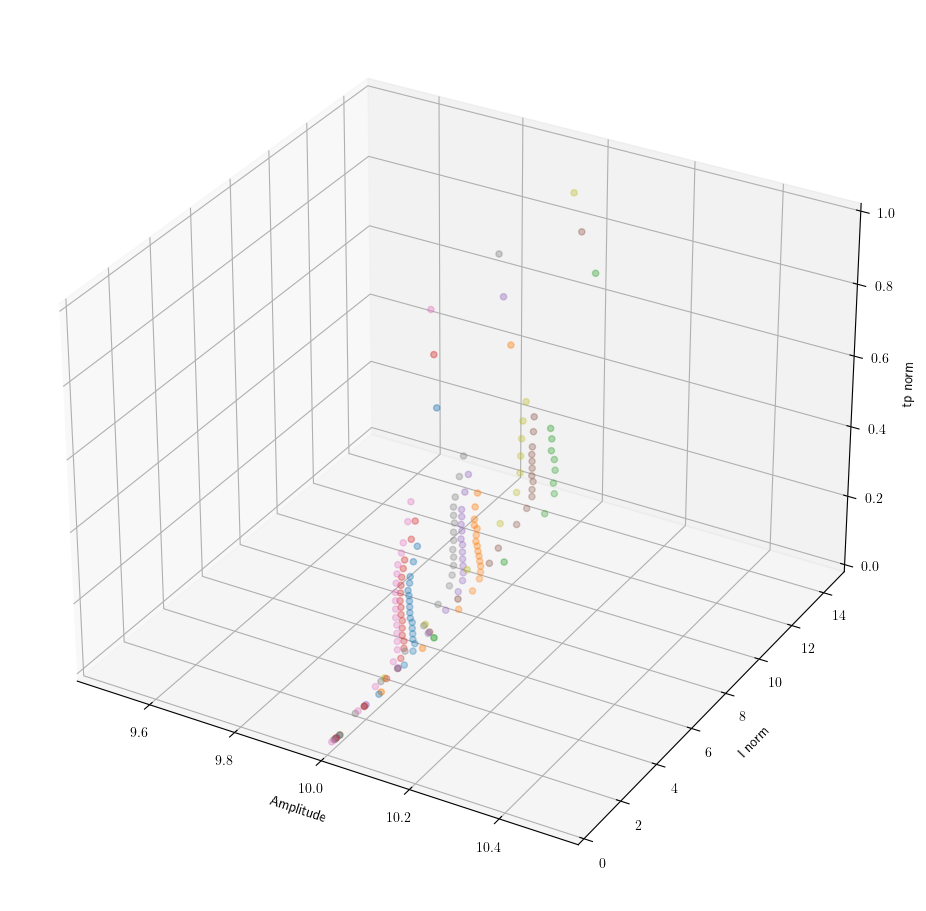

In [33]:
fig = plt.figure(figsize=(16, 9), constrained_layout=True)
ax = fig.add_subplot(projection='3d')
#this_volt_case = [10,20,50,100]
#this_amp_case  = np.unique(statistical_set[['Amplitude']].values)#[1,2.5,5,10,20,1000]
#this_emitter_size = [str([[125.0, 125.0, 0.0]])]#, str([[250.0, 250.0, 0.0]])]

for x in this_volt_case:
    errorset = statistical_set[statistical_set['Voltage']==x]
    for y in this_amp_case:
        nextset = errorset[errorset['Amplitude']==y]
        for z in this_emitter_size:
            thisset = nextset[ nextset['Emitter'] == z]
            ax.scatter3D(thisset['Amplitude'], thisset['norm_I'], thisset['norm_tp'])#, marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            #plt.plot(nextset['Amplitude'], nextset['Pulse_width'], marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
            #plt.plot(nextset['Pulse_width'], nextset['norm_I'])#, marker='o', ls='-', label=str(x)+'V '+str(y)+'Amp')
#plt.xlim([0,11])
ax.set_ylim(0,15)
ax.set_zlim(0,1)
#plt.legend()
ax.set_xlabel('Amplitude')
ax.set_ylabel('I norm')
ax.set_zlabel('tp norm')

plt.show()

In [34]:
# Create figure
fig, axs = plt.subplots(6,1,figsize=(16, 9), constrained_layout=True)
# Set title
#axs[0].set_title( str(voltage_case) + ' - 500nm² - ' + str(box_dimensions[2]) + 'nm AK gap - ' + amplitude_case)
# Label y-axii
axs[0].set_ylabel('Total Charge Collected [C]')
axs[1].set_ylabel('Max Ramo current [A]')
axs[2].set_ylabel('Emittance e_x')
axs[3].set_ylabel('Emittance e_y')
axs[4].set_ylabel('Brightness [A/(m-rad)^2]')
axs[5].set_ylabel('Pulse out / Pulse in')
# Label x-axis
axs[5].set_xlabel('Sigma [steps]')
# Testing
#errorset = errorset.groupby(['Voltage'])

# Plot error bar graph from statistical set
axs[0].errorbar(errorset['Pulse_width'], errorset['Q_mean' ],  yerr=errorset['Q_std' ],  marker='o', markersize=5, markerfacecolor='r',markeredgecolor='r', ecolor='k', capsize=4)
axs[1].errorbar(errorset['Pulse_width'], errorset['R_mean' ],  yerr=errorset['R_std' ],  marker='o', markersize=5, markerfacecolor='k',markeredgecolor='k', ecolor='k', capsize=4)
axs[2].errorbar(errorset['Pulse_width'], errorset['Ex_mean'],  yerr=errorset['Ey_std'],  marker='o', markersize=5, markerfacecolor='b',markeredgecolor='b', ecolor='k', capsize=4)
axs[3].errorbar(errorset['Pulse_width'], errorset['Ey_mean'],  yerr=errorset['Ey_std'],  marker='o', markersize=5, markerfacecolor='b',markeredgecolor='b', ecolor='k', capsize=4)
axs[4].errorbar(errorset['Pulse_width'], errorset['B_mean' ],  yerr=errorset['B_std' ],  marker='o', markersize=5, markerfacecolor='g',markeredgecolor='g', ecolor='k', capsize=4)
axs[5].errorbar(errorset['Pulse_width'], errorset['P_mean' ],  yerr=errorset['P_std' ],  marker='o', markersize=5, markerfacecolor='m',markeredgecolor='m', ecolor='k', capsize=4)
# Set axis limitations
axs[0].set_ylim((0, 2E-16))
for i in range(6):
    axs[i].set_xlim((0,150))


RuntimeError: latex was not able to process the following string:
b'Brightness [A/(m-rad)^2]'

Here is the full report generated by latex:
This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(../5081bbd382d369edafaa40cfcddee4e5.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/latex/geometry/geometry.sty
(/usr/share/texlive/texmf-dist/tex/latex/graphics/keyval.sty)
(/usr/share/texlive/texmf-dist/tex/generic/iftex/ifvtex.s

<Figure size 1600x900 with 6 Axes>

## Discreet emittance graphs

In [ ]:
fix = filepath.replace('laser','')
filepath = os.getcwd() + '/' + fix + 'out'
filename_ramo = os.path.join(filepath, 'ramo_current.dt') # Ramo current
filename_emission = os.path.join(filepath, 'emitted.dt') # Emitted Electrons
data = np.loadtxt(filename_ramo)
#cur_time, step, ramo_cur, V_d, nrPart, nrElec, nrHole, ((ramo_current_emit(j,i)/cur_scale, j=1, MAX_SECTIONS), i = 1, nrEmit)
cur_time = data[:, 0]
step = data[:, 1]
ramo_cur = data[:, 2]
#V_d = data[:, 3]
nrPart = data[:, 4]
nrElec = data[:, 5]
#nrHole = data[:, 6]
ramo_cur_sec_1 = data[:, 7]
ramo_cur_sec_2 = data[:, 8]
ramo_cur_sec_3 = data[:, 9]
ramo_cur_sec_4 = data[:, 10]

x_min = np.min(cur_time)
x_max = np.max(cur_time)

NameError: name 'filepath' is not defined

In [ ]:
filepath = '/home/hakon/Code/PE_Sim/500nm_square/50V/500Sigma_2.5Amp_Run6/out/'
filename_emission = filepath + 'emitted.dt' # Emitted Electrons
data = np.loadtxt(filename_emission)
emit_time = data[:, 0]
emit_step = data[:, 1]
emit_elec = data[:, 2]
emit_total = data[:, 3]
emit_nrElecs = data[:, 4]
#emit_nrHoles = data[:, 5]
#emit_pulse = data[:, 6]
tot_emit_elec = 0
charge_in = []
for j in range(len(emit_elec)):
    tot_emit_elec = tot_emit_elec + emit_elec[j]
    #charge = sum(ramo_cur)
    charge_in.append(tot_emit_elec)

In [ ]:
#filepath = '/home/cryptek/Code/PE Simulations/500nm_square/10V/Sigma10.0_Amp_3.037_Run1/out/'
filename_absorbed = filepath + 'absorbed_top.dt' # Absorbed Electrons
data = np.loadtxt(filename_absorbed)
absor_time = data[:, 0]
absor_step = data[:, 1]
absor_elec = data[:, 2]
tot_absor_elec = 0
charge_out = []
for j in range(len(absor_elec)):
    tot_absor_elec = tot_absor_elec + absor_elec[j]
    #charge = sum(ramo_cur)
    charge_out.append(tot_absor_elec)


In [ ]:
filename_absorbed = filepath + 'absorbed_bot.dt' # Absorbed Electrons
data = np.loadtxt(filename_absorbed)
absor_bot_time = data[:, 0]
absor_bot_step = data[:, 1]
absor_bot_elec = data[:, 2]

In [ ]:
#plt.plot(emit_time, emit_total)
plt.plot(absor_time, absor_elec)
#plt.plot(absor_time, charge_out)
plt.plot(emit_time, emit_elec)
#plt.plot(emit_time, charge_in)
#plt.plot(cur_time, ramo_cur*10000000)
#plt.plot(absor_bot_time, absor_bot_elec)

#plt.title('Test')
plt.xlabel('Time (ps)')
plt.ylabel('Nr Elec')
plt.xlim([4,7])
plt.show()

In [ ]:
plt.plot(cur_time, nrElec)
#plt.title('Test')
plt.xlabel('Time (ps)')
plt.ylabel('Nr Elec')

In [ ]:
plt.plot(cur_time, ramo_cur)
plt.title('Ramo Current')
plt.xlabel('Time [ps]')
plt.ylabel('Current [A]')